# Load modules

In [1]:
import os
import cv2
import sys
import glob
import imageio
import numpy as np
import pandas as pd
import nibabel as nib
import pydicom as dcm
import matplotlib.pyplot as plt
from datetime import datetime as dtime


# Auxiliar Functions

In [2]:
def displayDICOMimage(DICOMobj):
    plt.figure(1)
    plt.imshow(DICOMobj.pixel_array,plt.cm.gray)
    plt.show()

def getenv():
    """
    Requires sys and os modules:
    import sys
    import os
    """
    if sys.platform == 'win32':
        env_home = 'HOMEPATH'
    elif (sys.platform == 'darwin') | (sys.platform == 'linux'):
        env_home = 'HOME'
    HOMEPATH = os.getenv(env_home)
    
    return HOMEPATH

def check_path_exist(path, file=False):
    """
    Flag FILE indicates the path contains a file name (FLAG=TRUE) or the path only points to a folder (FLAG=FALSE (Default))
    """
    if file:
        is_path = os.path.isfile(path)
    else:
        is_path = os.path.isdir(path)

    print(f'{"OK:" if is_path else "ERROR:"} Path to {"file" if file else "folder"} {path} does{"" if is_path else " NOT"} exist')

    return is_path

def list_folder(path, skip_patterns=None, sorted=False):
    # Check the path exists:
    if not(os.path.isdir(path)):
        error_message = f'[ERROR]: Folder path {path} does not exist'
        sys.exit(error_message)
    
    raw_list = os.listdir(path)
    
    # Ensure patterns is a list, defaulting to ['.DS_Store']
    dsStorePattern = '.DS_Store'
    if skip_patterns is None:
        skip_patterns = [dsStorePattern]
    elif isinstance(skip_patterns, str):
        skip_patterns = [dsStorePattern, skip_patterns]  # Convert single string to list
    elif isinstance(skip_patterns, (list, tuple, set)):  
        skip_patterns = list(skip_patterns)  # Ensure it's a list
        if dsStorePattern not in skip_patterns:
            skip_patterns.append(dsStorePattern)  # Add default pattern if not already included
    else:
        raise TypeError("patterns must be a string, list, tuple, or set.")

    # dir_list = [item for item in raw_list if skip_pattern not in item]
    # any(p in item for p in skip_patterns) checks if any pattern in skip_patterns exists in item:
    dir_list = [item for item in raw_list if not any(p in item for p in skip_patterns)]

    if sorted:
        dir_list.sort()

    return dir_list


# Function to parse mixed datetime formats
def parse_mixed_datetime(ts, format='%Y%m%d%H%M%S.%f'):
    """
    # Ensure all values have milliseconds (force `.0000` if missing) before the conversion:
    """

    ts_f = ts.apply(lambda x: f"{x}.0000" if pd.notna(x) and "." not in str(x) else x)

    return pd.to_datetime(ts_f, format=format, errors="coerce")
    

In [3]:
def load_dicom_file(path_to_dicom_file, tags_to_read, read_pixel_tag=False):

    # Reads an individual DICOM file and returns the metadata and image (if required)

    dcm_object = dcm.dcmread(path_to_dicom_file, stop_before_pixels = not(read_pixel_tag))

    dcm_metadata_fields = flatten_tags_dictionary(tags_to_read)
    dcm_metadata = [None]*len(dcm_metadata_fields)

    for tagSubSetName, tagSubSetFields in tags_to_read.items():
        # print(f'TagSubSetName: {tagSubSetName}')
        for tagName, tagValue in tagSubSetFields.items():
            try:
                dcm_metadata[dcm_metadata_fields.index(tagName)] = dcm_object[tagValue['hex']].value
            except:
                # print(f'Attribute {tagName} does not exist, skipping it...')
                pass
    
    # Add the filepath:
    dcm_metadata[dcm_metadata_fields.index('AbsFilePath')] = path_to_dicom_file
    dicom_object = {'metadata': dcm_metadata}

    if read_pixel_tag:
        dicom_object['image'] = dcm_object.pixel_array

    return dicom_object 


def flatten_tags_dictionary(tag_dictionary):
    # TAG_DICTIONARY is a 2-level dictionary
    # The output is a 1-d list containing the 2nd level tags 

    upper_level_tags = tag_dictionary.keys()
    flattened_tags = []
    for ul_tag in upper_level_tags:
        subsetDataLabels = list(tag_dictionary[ul_tag].keys())
        flattened_tags += subsetDataLabels

    # Add the absolute filepath to the dataframe:
    flattened_tags.append('AbsFilePath')

    return flattened_tags


In [4]:
def get_image_dataset(dataset_df, patientID, visit_to_load, sequenceNamePattern, use_philips_rescale=True):

    df_metadata_patient = dataset_df[dataset_df['PatientID'] == patientID]

    visits_in_patient = df_metadata_patient['StudyDate'].unique().tolist()
    visits_in_patient.sort()

    scanDate = visits_in_patient[ visit_to_load - 1 ]

    df_metadata_patient_visit = df_metadata_patient[df_metadata_patient['StudyDate'] == scanDate]

    df_metadata_patient_visit_sequence = df_metadata_patient_visit[df_metadata_patient_visit['SeriesDescription'].str.startswith(sequenceNamePattern)].copy()
    # Sort by slice location, then by TemporalPositionIdentifier and then load the images 
    # (the copy() above is to avoid the SettingWithCopyWarning message when inplace sorting)
    df_metadata_patient_visit_sequence.sort_values(by=['z', 'TemporalPositionIdentifier'], inplace=True)

    sequenceName = df_metadata_patient_visit_sequence['SeriesDescription'].unique()[0]

    scanTime = df_metadata_patient_visit_sequence.SeriesTime.unique()
    if len(scanTime) > 1:
        print('WARNING: Scan Time registered for the sequence is no unique!, if this is ok, ignore this message')
    scanDateTime = dtime.strptime("-".join([scanDate, scanTime[0]]), "%Y%m%d-%H%M%S.%f")


    print(f'Selected Patient {patientID}, visit {visit_to_load}, Sequence {sequenceName} (from {dtime.strftime(scanDateTime, "%d/%m/%Y @%H:%M:%S")})')


    # Characterise the size of the dataset
    # Rows and Columns must be the same for the whole series:
    nrows_list = df_metadata_patient_visit_sequence['Rows'].unique()
    ncols_list = df_metadata_patient_visit_sequence['Columns'].unique()
    if (len(nrows_list) > 1) | (len(ncols_list)>1):
        print(f'WARNING: Either the number of ROWS ({nrows_list}) or COLUMNS ({ncols_list}) is not consistent for the Series')
    [w, h] = [ncols_list[0], nrows_list[0]]

    slice_locations = df_metadata_patient_visit_sequence['z'].unique()
    ns = len(slice_locations)

    number_of_temporal_positions = df_metadata_patient_visit_sequence['NumberOfTemporalPositions'].unique()
    # numberOfTempPositions must be only 1 element length, because it must be the same for a single Series (afaik)
    temporal_positions = df_metadata_patient_visit_sequence['TemporalPositionIdentifier'].unique()

    if len(number_of_temporal_positions) > 1:
        print(f'WARNING: Check you are processing only one series, the length of temporal_positions is {len(number_of_temporal_positions)}')
        sys.exit()
    nt = number_of_temporal_positions[0]

    print(f'Dataset {patientID}-{scanDate}-{sequenceName} contains {ns} slices and {nt} temporal positions of size {w}x{h} (WxH)')

    # Image resolution and slice spacing
    # df_metadata_patient_visit_sequence['PixelSpacing']
    [resRows, resCols]= df_metadata_patient_visit_sequence['PixelSpacing'].apply(pd.Series).T.values.tolist()
    deltaRow, deltaCol = [np.unique(resRows), np.unique(resCols)]

    # resolution along the slice direction:
    delta_z = df_metadata_patient_visit_sequence['SliceThickness'].unique()

    if (len(deltaRow) > 1) | (len(deltaCol) > 1) | (len(delta_z) > 1):
        print('WARNING: Check you are processing only one series')
        print(f'\t the length of the resolutions parameters is not 1 for Rows ({len(deltaRow)}), Columns ({len(deltaCol)}) and/or slice ({len(delta_z)})')
        sys.exit()

    resx_W, resy_H, resz_Z = [deltaRow[0], deltaCol[0], delta_z[0]]
    print(f'Image resolution is {resx_W:.3f}x{resy_H:.3f}x{resz_Z:.2f} [mm/pixel] (WxHxZ)')


    # Load the data, remember the dataframe is already sorted by slice->time:
    # Remember the array order in numpy is W(rows), H(cols), Z(slice)
    image4D = np.full((w, h, ns, nt), np.nan)
    timeaxis_spatial_temporal = np.full((ns, nt), np.nan)
    zlocation_spatial_temporal = np.full((ns, nt), np.nan)

    for dicom_file_row, dicom_datafile in df_metadata_patient_visit_sequence.iterrows():
        dcm_object = dcm.dcmread(dicom_datafile['AbsFilePath'])
        slice_position = slice_locations.tolist().index(dicom_datafile["z"])
        time_position = temporal_positions.tolist().index(dicom_datafile["TemporalPositionIdentifier"])

        dcm_image_32bit = dcm_object.pixel_array.astype(np.float32)
        # if rescale:
        # According to this thread https://stackoverflow.com/questions/67889762/what-is-the-difference-between-rescale-slope-intercept-and-scale-slope-inter
        # The forumalea relevant are:
        # D = R * RS + RI; R= raw pixel value, RS Rescale Slope (0028,1053), RI Rescale Intercept (0028,1052)
        # P = D / (RS * SS); D= Displayed Value (in the scanner screen), RS Rescale Slope (0028,1053), SS Scale Slope (2005,100E) "PhilipsScaleSlope"
        dcm_image_32bit *= dicom_datafile['RescaleSlope']
        dcm_image_32bit += dicom_datafile['RescaleIntercept']
        if use_philips_rescale:
            dcm_image_32bit /= (dicom_datafile['RescaleSlope'] * dicom_datafile['PhilipsScaleSlope'])

        image4D[:,:,slice_position, time_position] = dcm_image_32bit
        # Get the timing (secs) and location (mm) of each slice, in secs. It allows to easily get the time axis when plotting the data
        timeaxis_spatial_temporal[slice_position, time_position] = dicom_datafile['perSliceAcquisitionTimeInSecs']
        zlocation_spatial_temporal[slice_position, time_position] = dicom_datafile['z']
    
    scanDetails = {'scanDateTime': scanDateTime,
                   'sequenceName': sequenceName,
                   'TR': df_metadata_patient_visit_sequence['RepetitionTime'].unique().tolist(),
                   'TE': df_metadata_patient_visit_sequence['EchoTime'].unique().tolist(),
                   'FA': df_metadata_patient_visit_sequence['FlipAngle'].unique().tolist(),
                   'ETL': df_metadata_patient_visit_sequence['EchoTrainLength'].unique().tolist()
                   }

    return image4D, zlocation_spatial_temporal, timeaxis_spatial_temporal, scanDetails


# Default DICOM tags

In [5]:
Tag2proc = {
'ID': { # Patient and Study ID
            'StudyID': {'hex': 0x00200010,
                         #  'type': str
                         },
            'PatientName': {'hex': 0x00100010,
                         #    'type': str
                            },
            'PatientID': {'hex': 0x00100020,
                         #  'type': str
                         }
     },
'SeriesID': { # Acquisitions and Series ID
            'SeriesDescription': {'hex': 0x0008103e,
                         #  'type': str
                         },
            'SeriesNumber': {'hex': 0x00200011,
                         #  'type': pd.Int64Dtype()
                         },
            'AcquisitionNumber': {'hex': 0x00200012,
                              #     'type': pd.Int64Dtype()
                                  },
            'InstanceNumber':{'hex': 0x00200013,
                              # 'type': pd.Int64Dtype()
                             }
            # 'ImagesInAcquisition': {'hex': 0x00201002,
            #                   #     'type': pd.Int64Dtype()
            #                       }
          },
'DatesTimes': { #  Dates & Times
            'StudyDate': {'hex': 0x00080020,
                         #  'type': str
                         },
            'StudyTime': {'hex': 0x00080030,
                         #  'type': str
                         },
            'SeriesDate': {'hex': 0x00080021,
                         #  'type': str
                         },
            'SeriesTime': {'hex': 0x00080031,
                         #  'type': str
                         },
            'AcquisitionDate': {'hex': 0x00080022,
                         #  'type': str
                         },
            'AcquisitionTime': {'hex': 0x00080032,
                         #  'type': str
                         },
          #   'AcquisitionDateTime': {'hex': 0x0008002A,
          #                          'type': str
          #                },
            'AcquisitionDuration': {'hex': 0x00189073, # Duration of the single continuous gathering of data over a period of time that resulted in this instance, in seconds.
                                   #  'type': pd.Float64Dtype()
                                    },
            'ContentDate': {'hex': 0x00080023,
                         #  'type': str
                         },
            'ContentTime': {'hex': 0x00080033,
                         #    'type': str
                            },
            'InstanceCreationDate': {'hex': 0x00080012,
                         #  'type': str
                         },
            'InstanceCreationTime': {'hex': 0x00080013,
                         #  'type': str
                         },
            'PerformedProcedureStepEndDate': {'hex': 0x00400250,
                         #  'type': str
                         },
            'PerformedProcedureStepEndTime': {'hex': 0x00400251,
                         #  'type': str
                         }
          },
'AcqPars': { # Acquisition Parameters
            'ImageType': {'hex': 0x00080008,
                        #   'type': 
                        },
            'ScanningSequence': {'hex': 0x00180020,
                                 },
            'SequenceVariant': {'hex': 0x00180021,
                                 },
            'ScanOptions': {'hex': 0x00180022, # Parameters of scanning sequence.
                         #    'type': str
                            },
            'MRAcquisitionType': {'hex': 0x00180023,
                              #     'type': str
                                  },
            'SequenceName': {'hex': 0x00180024, 
                         #    'type': str
                            },
            'RepetitionTime': {'hex': 0x00180080,
                              #  'type': pd.Float64Dtype()
                               },
            'EchoTime': {'hex': 0x00180081,
                         # 'type': pd.Float64Dtype()
                         },
            'FlipAngle': {'hex': 0x00181314,
                         #  'type': pd.Float64Dtype()
                          },
            'InversionTime': {'hex': 0x00180082,
                              # 'type': pd.Float64Dtype()
                         },
            'NumberOfAverages': {'hex': 0x00180083,
                              # 'type': pd.Int64Dtype()
                         },
            'NumberOfPhaseEncodingSteps': {'hex': 0x00180089,
                                        #    'type': pd.Int64Dtype()
                                           },
            'EchoTrainLength': {'hex': 0x00180091,
                              #   'type': pd.Int64Dtype()
                                },
            'PercentSampling': {'hex': 0x00180093,
                              #   'type': pd.Float64Dtype()
                                },
            'PercentPhaseFieldOfView': {'hex': 0x00180094,
                                        # 'type': pd.Float64Dtype()
                                        },
            'PixelBandwidth': {'hex': 0x00180095,
                              #  'type': pd.Float64Dtype()
                               },
            'TriggerTime': {'hex': 0x00181060, # Time, in msec, between peak of the R wave and the peak of the echo produced
                         #    'type': pd.Float64Dtype()
                            },
            'InPlanePhaseEncodingDirection': {'hex': 0x00181312,
               #   'type': str
                 },
            'TemporalPositionIdentifier': {'hex': 0x00200100,
               #   'type': str
                 },
            'NumberOfTemporalPositions': {'hex': 0x00200105,
                                        #   'type': str
                                          },
            # 'TemporalResolution': {'hex': 0x00200110,
            #                             #   'type': str
            #                               },
            'SliceLocation':{'hex': 0x00201041,
                         #     'type': pd.Float64Dtype()
                            },
            'ImagePositionPatient':{'hex': 0x00200032,
                                   #  'type': object
                                    },
            'SliceThickness': {'hex': 0x00180050,
                              #  'type': pd.Float64Dtype()
                               },
            'SpacingBetweenSlices': {'hex': 0x00180088,
                                   #   'type': pd.Float64Dtype()
                              },
            'ImageOrientationPatient': {'hex': 0x00200037,
                                        # 'type': object
                              },
          },
'ImagePars': { # Reconstruction/Image Parameters
            'AcquisitionMatrix': {'hex': 0x00181310,
                              #     'type': object
                                  },
            'PixelSpacing': {'hex': 0x00280030,
                         #     'type': object
                             },
            'Rows': {'hex': 0x00280010,
                    #  'type': pd.Int64Dtype()
                     },
            'Columns': {'hex': 0x00280011,
                    #     'type': pd.Int64Dtype()
                        },
            # 'PixelAspectRatio': {'hex': 0x00280034,
            #                   #    'type': object
            #                      },
            'ReconstructionDiameter': {'hex': 0x00181100,
                                   #     'type': pd.Float64Dtype()
                                       },
            'RescaleType': {'hex': 0x00281054,
                         #    'type': str
                            },
            'RescaleIntercept': {'hex': 0x00281052, # RI
                         #    'type': pd.Float64Dtype()
                            },
            'RescaleSlope': {'hex': 0x00281053, # RS
                         #    'type': pd.Float64Dtype()
                            },
            # 'PhilipsRWVSlope': {'hex': 0x00409225,  # Philips Private Attribute
            #                   #   'type': pd.Float64Dtype()
            #                    },
            # 'PhilipsRWVIntercept': {'hex': 0x00409224,  # WI, Philips Private Attribute
            #                        #  'type': pd.Float64Dtype()
            #                         },
            'PhilipsScaleSlope': {'hex': 0x2005100E, # SS, Philips Private Attribute
                              #     'type': pd.Float64Dtype()
                                  }
            # 'PhaseNumber': {'hex': 0x20011008, # Philips Private Attribute
            #              #    'type': pd.Int64Dtype()
            #                 }
          },
'ContrastAgent': { # Contrast Agent
            'ContrastBolusAgent': {'hex': 0x00180010,
                         #  'type': str
                         },
            'ContrastBolusRoute': {'hex': 0x00181040,
                         #  'type': str
                         },
            'ContrastBolusVolume': {'hex': 0x00181041,
                         #  'type': pd.Float64Dtype()
                         },
            'ContrastBolusStartTime': {'hex': 0x00181042,
                         #  'type': pd.Float64Dtype()
                         },
            'ContrastBolusStopTime': {'hex': 0x00181043,
                         #  'type': pd.Float64Dtype()
                         },
            'ContrastBolusTotalDose': {'hex': 0x00181044,
                         #  'type': pd.Float64Dtype()
                         },
            'ContrastFlowRate': {'hex': 0x00181046,
                         #  'type': pd.Float64Dtype()
                         },
          }
   }

metaDataFields = flatten_tags_dictionary(tag_dictionary=Tag2proc)


# Path to files and dicom file extension

In [6]:
HOMEPATH = getenv()
FEXT = 'dcm'


In [7]:
# If running data from Phase 2 (2025), raw data structure is more organised:
DATAPATH = os.path.join(HOMEPATH, 'Data', 'FTV_DCEMRI_Phase02')
DICOMPATH = os.path.join(DATAPATH, 'DICOM')
OUTPATH = os.path.join(DATAPATH, 't1vfa')
# If needed, create the OUTPUTPATH:
os.makedirs(OUTPATH, exist_ok=True)
# Inside DICOM, there is a list of patients with each one containing the study date and inside them, the data:
!tree -L 3 {DICOMPATH} 


/Users/joseulloa/Data/FTV_DCEMRI_Phase02/DICOM
├── 001
│   ├── 2022-10__Studies
│   │   ├── NE001_ANON58704_MR_2022-10-26_135058_MRI.Sim.Breast.Prone.+.Contrast_4D.THRIVE.Ultrafast_n2400__00000
│   │   ├── NE001_ANON58704_MR_2022-10-26_135058_MRI.Sim.Breast.Prone.+.Contrast_Dyn.eTHRIVE_n1080__00000
│   │   ├── NE001_ANON58704_MR_2022-10-26_135058_MRI.Sim.Breast.Prone.+.Contrast_FA15.THRIVE.map_n120__00000
│   │   └── NE001_ANON58704_MR_2022-10-26_135058_MRI.Sim.Breast.Prone.+.Contrast_FA5.THRIVE.map_n120__00000
│   └── 2022-12__Studies
│       ├── NE001_ANON58704_MR_2022-12-15_103927_MRI.Sim.Breast.Prone.+.Contrast.Post.Tmt_4D.TH_n2400__00000
│       ├── NE001_ANON58704_MR_2022-12-15_103927_MRI.Sim.Breast.Prone.+.Contrast.Post.Tmt_Dyn.eTHRIVE_n1080__00000
│       ├── NE001_ANON58704_MR_2022-12-15_103927_MRI.Sim.Breast.Prone.+.Contrast.Post.Tmt_FA15.THRIVE.map_n120__00000
│       └── NE001_ANON58704_MR_2022-12-15_103927_MRI.Sim.Breast.Prone.+.Contrast.Post.Tmt_FA5.THRIVE.map_n120__00000

# Load all the (meta) data and construct a master DataFrame

In [8]:
# Get the list of outer folders (Patient Keys):
patientsList = list_folder(DICOMPATH, sorted=True)
dicomMetadataList = []

# Construct the dataframe for each patient
#   1)  Inside each patient, there should be one or two folders, 
#       corresponding to the study date (i.e. at least 2 visits per patient)
for patient in patientsList:
    path_to_patient = os.path.join(DICOMPATH, patient)
    print(f'Processing patient {patient} folder {path_to_patient}')
    # Get the study dates:
    visit_dates = list_folder(path_to_patient, sorted=True)
    print(f'Patient {patient} folder contains sub-folders: {visit_dates}')
    for visit in visit_dates:
        path_to_visit = os.path.join(path_to_patient, visit)
        # Get series within the study date:
        series_list = list_folder(path_to_visit, sorted=True)
        print(f'\tVisit {visit} folder containts the {len(series_list)} scan series')
        # Loading the dcm files on each series folder:
        for series in series_list:
            path_to_series = os.path.join(path_to_visit, series)
            # Get the list of DCM (or whatever is defined by FEXT) files:
            dcmlist = glob.glob(os.path.join(path_to_series,f'*.{FEXT}'))
            # print(f'There are {len(dcmlist)} files in {"-".join([patient, visit, series])}')
            # print('Loading dicom files, please wait...')
            for dcmfile in dcmlist:
                dcm_metadata_row = load_dicom_file(dcmfile, tags_to_read=Tag2proc, read_pixel_tag=False)
                dicomMetadataList.append(dcm_metadata_row['metadata'])
print('All done')


Processing patient 001 folder /Users/joseulloa/Data/FTV_DCEMRI_Phase02/DICOM/001
Patient 001 folder contains sub-folders: ['2022-10__Studies', '2022-12__Studies']
	Visit 2022-10__Studies folder containts the 4 scan series
	Visit 2022-12__Studies folder containts the 4 scan series
Processing patient 002 folder /Users/joseulloa/Data/FTV_DCEMRI_Phase02/DICOM/002
Patient 002 folder contains sub-folders: ['2022-12__Studies', '2023-01__Studies']
	Visit 2022-12__Studies folder containts the 4 scan series
	Visit 2023-01__Studies folder containts the 4 scan series
Processing patient 004 folder /Users/joseulloa/Data/FTV_DCEMRI_Phase02/DICOM/004
Patient 004 folder contains sub-folders: ['2023-04__Studies', '2023-05__Studies']
	Visit 2023-04__Studies folder containts the 4 scan series
	Visit 2023-05__Studies folder containts the 4 scan series
Processing patient 005 folder /Users/joseulloa/Data/FTV_DCEMRI_Phase02/DICOM/005
Patient 005 folder contains sub-folders: ['2023-06__Studies', '2023-07__Stud

In [9]:
df_metadata = pd.DataFrame(columns=metaDataFields, data=dicomMetadataList)#.astype(dtype_df_dict)
# Create datetime objects for the paired date and time attributes
date_time_attr = ['InstanceCreation', 'Study', 'Series', 'Acquisition', 'Content']

for datetime_tagName in date_time_attr:
    date_attr = datetime_tagName+'Date'
    time_attr = datetime_tagName+'Time'
    df_metadata[datetime_tagName+'DateTime'] = parse_mixed_datetime(df_metadata[date_attr] + df_metadata[time_attr])

# Additionally, merges the Study Date with Contrast Start/End to ensure they fit in the acquisition window:
df_metadata['ContrastBolusStartDateTime'] = parse_mixed_datetime(df_metadata['StudyDate'] + df_metadata['ContrastBolusStartTime'])
df_metadata['ContrastBolusEndDateTime'] = parse_mixed_datetime(df_metadata['StudyDate'] + df_metadata['ContrastBolusStopTime'])

# Ensures PatientName is a string:
df_metadata['PatientName'] = df_metadata['PatientName'].astype(str)

# Setup a per-slice timing:
# For each Series do the following:
#   - Sort, in ascending order, the TemporalPositionIdentifier
#   - Sort, in ascending order, the slice location (from - to +)
#   - Based on the dataframe index, loop over the Temporal position and populate the new field AcquisitionDateTimeSlice:
# 
df_metadata['perSliceAcquisitionTime'] = [None]*len(df_metadata)
df_metadata['perSliceAcquisitionTimeInSecs'] = [None]*len(df_metadata)
df_metadata['ContrastBolusStartTimeInSecs'] = [None]*len(df_metadata)

# Patient List:
patientList = df_metadata['PatientName'].unique().tolist()
for patient in patientList:
    # Studies List for each patient:
    patient_in_df = df_metadata[df_metadata['PatientName'].isin([patient])]
    studies_in_patient = patient_in_df['StudyDate'].unique().tolist()
    for study_patient in studies_in_patient:
        study_in_patient = patient_in_df[patient_in_df['StudyDate'].isin([study_patient])]
        sequences_in_study = study_in_patient['SeriesDescription'].unique().tolist()
        # min acquisition time between Dyn eTHRIVE and 4D_THRIVE:
        df_aux = study_in_patient[(study_in_patient['SeriesDescription'].str.startswith('4D_THRIVE')) | (study_in_patient['SeriesDescription'].str.startswith('Dyn'))]
        min_time = df_aux['AcquisitionDateTime'].min(skipna=True)
        for sequence_study_patient in sequences_in_study:
            # We're now at the level of series.
            # For the timming, we're only interested in 4D_THRIVE_Ultrafast & Dyn eTHRIVE:
            if sequence_study_patient.startswith('4D_THRIVE') | sequence_study_patient.startswith('Dyn'):
                serie_in_study = study_in_patient[study_in_patient['SeriesDescription'].isin([sequence_study_patient])]
                # Additional Filter to remove the corrupted single file:
                serie_in_study = serie_in_study[serie_in_study['AcquisitionNumber'].notna()]
                # Now, we should be ready to assign the timings:
                # Sort by temporal position:
                serie_in_study.sort_values(by=['TemporalPositionIdentifier', 'SliceLocation'], ascending=(True, False), inplace=True)
                nslices = len(serie_in_study['SliceLocation'].unique().tolist())
                slice_order = range(0, nslices)
                # Here loop over TimePos and slice location using the formula:
                # AcquisitionTime  + TR * TempPos * Range(Slice)
                TR = serie_in_study['RepetitionTime'].unique().tolist()
                if len(TR) > 1:
                    print(f'WARNING!: There are more than 1 TR ({TR}) in the series. Using the first one available')
                # else:
                    # print(f'TR: {TR[0]}ms')
                TR = TR[0]

                nt = serie_in_study['NumberOfTemporalPositions'].unique().tolist()
                if len(nt) > 1:
                    print(f'ERROR: The number of temporal positions {nt} is not consistent through the series')
                    sys.exit()
                # else:
                    # print(f'Number of Temporal Positions: {nt[0]}')                
                nt = int(nt[0])
                slices_positions = list(slice_order)*nt
                perSliceAcquisitionDateTime = pd.to_timedelta([z*TR/1000.0 for z in slices_positions], unit='s')
                # serie_in_study['perSliceAcquisitionDateTime'] = [None]*len(serie_in_study)
                serie_in_study['perSliceAcquisitionDateTime'] = serie_in_study['AcquisitionDateTime'] + perSliceAcquisitionDateTime
                
                # Find the earliest AcquisitionEndTime (ignoring NaT values) -- But the min time in my case, is the start of the Dyn eTHRIVE acquisition
                # min_time = serie_in_study['perSliceAcquisitionDateTime'].min(skipna=True)
                # Compute time differences in seconds for the acquisition and contrast bolus
                serie_in_study['perSliceAcquisitionTimeInSecs'] = (serie_in_study['perSliceAcquisitionDateTime'] - min_time).dt.total_seconds()
                serie_in_study['ContrastBolusStartTimeInSecs'] = (serie_in_study['ContrastBolusStartDateTime'] - min_time).dt.total_seconds()

                df_metadata.loc[serie_in_study.index, 'perSliceAcquisitionDateTime'] = serie_in_study['perSliceAcquisitionDateTime']
                df_metadata.loc[serie_in_study.index, 'perSliceAcquisitionTimeInSecs'] = serie_in_study['perSliceAcquisitionTimeInSecs']
                df_metadata.loc[serie_in_study.index, 'ContrastBolusStartTimeInSecs'] = serie_in_study['ContrastBolusStartTimeInSecs']

                # for index, tpos, zpos in zip(serie_in_study.index, serie_in_study['TemporalPositionIdentifier'], slices_positions):
                #     # # df_metadata.loc[index, 'perSliceAcquisitionTime'] = TR*zpos
                #     serie_in_study.loc[index, 'perSliceAcquisitionDateTime'] = TR*zpos
                


# convert df_metadata['perSliceAcquisitionTime'] to numeric and then to timedelta in seconds:
# df_metadata['perSliceAcquisitionTime'] = pd.to_timedelta(pd.to_numeric(df_metadata['perSliceAcquisitionTime'], errors='coerce'), unit='ms')
# And then sum up the Acquisition DateTime so it becomes datetime too:
# df_metadata['perSliceAcquisitionDateTime'] = df_metadata['AcquisitionDateTime'] + df_metadata['perSliceAcquisitionTime']
# Add time axis in minutes too:
df_metadata[['perSliceAcquisitionTimeInMins', 'ContrastBolusStartTimeInMins']] = df_metadata[['perSliceAcquisitionTimeInSecs', 'ContrastBolusStartTimeInSecs']]/60.0

# Slicer3D uses the image position patient coordinate, rather than SliceLocation:
df_metadata[['x','y','z']] = df_metadata['ImagePositionPatient'].apply(pd.Series)

# Assigns patient number (taken from the folder name) to match with the patientID field
patientIDnro = df_metadata['AbsFilePath'].str.replace(DICOMPATH, '').str.split('/').apply(pd.Series)[1]
df_metadata['PatientIDNumber'] = patientIDnro

df_metadata.head()


,StudyID,PatientName,PatientID,SeriesDescription,SeriesNumber,AcquisitionNumber,InstanceNumber,StudyDate,StudyTime,SeriesDate,...,perSliceAcquisitionTime,perSliceAcquisitionTimeInSecs,ContrastBolusStartTimeInSecs,perSliceAcquisitionDateTime,perSliceAcquisitionTimeInMins,ContrastBolusStartTimeInMins,x,y,z,PatientIDNumber
0,ANON58704,NE001,ANON58704,4D_THRIVE_Ultrafast,901,9,1686,20221026,135058,20221026,...,None,295.625912,242.97,2022-10-26 14:22:05.865912001,4.927099,4.0495,-174.333301,-92.274017,-70.418083,001
1,ANON58704,NE001,ANON58704,4D_THRIVE_Ultrafast,901,9,258,20221026,135058,20221026,...,None,252.548101,242.97,2022-10-26 14:21:22.788100804,4.209135,4.0495,-174.333301,-92.274017,-52.418083,001
2,ANON58704,NE001,ANON58704,4D_THRIVE_Ultrafast,901,9,1063,20221026,135058,20221026,...,None,274.558605,242.97,2022-10-26 14:21:44.798604823,4.575977,4.0495,-174.333301,-92.274017,75.081917,001
3,ANON58704,NE001,ANON58704,4D_THRIVE_Ultrafast,901,9,539,20221026,135058,20221026,...,None,259.950579,242.97,2022-10-26 14:21:30.190579213,4.33251,4.0495,-174.333301,-92.274017,9.081917,001
4,ANON58704,NE001,ANON58704,4D_THRIVE_Ultrafast,901,9,1776,20221026,135058,20221026,...,None,296.092328,242.97,2022-10-26 14:22:06.332328022,4.934872,4.0495,-174.333301,-92.274017,64.581917,001


In [10]:
# Patients: 
patientsID = df_metadata['PatientID'].unique()
patientsIndice = df_metadata['PatientIDNumber'].unique()
patient_dictionary = dict(zip(patientsIndice, patientsID))

print(patientsIndice)


['001' '002' '004' '005' '006' '008' '009']


# Load individual datasets for a patient and visit

Having the master dataframe, it is straightforward to select an individual patient and visit and then load the corresponding datasets.

The following are the datasets available:


In [11]:
# Selection of Dataset:
patientIdx = '001'
patient_to_load = patient_dictionary[patientIdx]

visit_to_load = 1 # 1 or 2

sequence_to_load = 'FA5' # 'FA5', 'FA15', 'Dyn', '4D'


image4D, slice_position_matrix, abs_time_matrix, scanDetails = get_image_dataset(df_metadata, patient_to_load, visit_to_load, sequence_to_load)

[w, h, ns, nt] = image4D.shape


Selected Patient ANON58704, visit 1, Sequence FA5_THRIVE_map (from 26/10/2022 @14:18:10)
Dataset ANON58704-20221026-FA5_THRIVE_map contains 120 slices and 1 temporal positions of size 576x576 (WxH)
Image resolution is 0.619x0.619x3.00 [mm/pixel] (WxHxZ)


In [12]:
# Display some of the slices for checking and comparison
[figWidth, figHeight] = [5.0, 5.0]
nfigs = 9
ncols = int(np.ceil(np.sqrt(nfigs)))
nrows = int(np.ceil(nfigs/ncols))

# Get the slice timmings:
ref_time_sec = abs_time_matrix[0,0]
time_matrix = abs_time_matrix - ref_time_sec

# Initialise random Generator object
rng = np.random.default_rng()


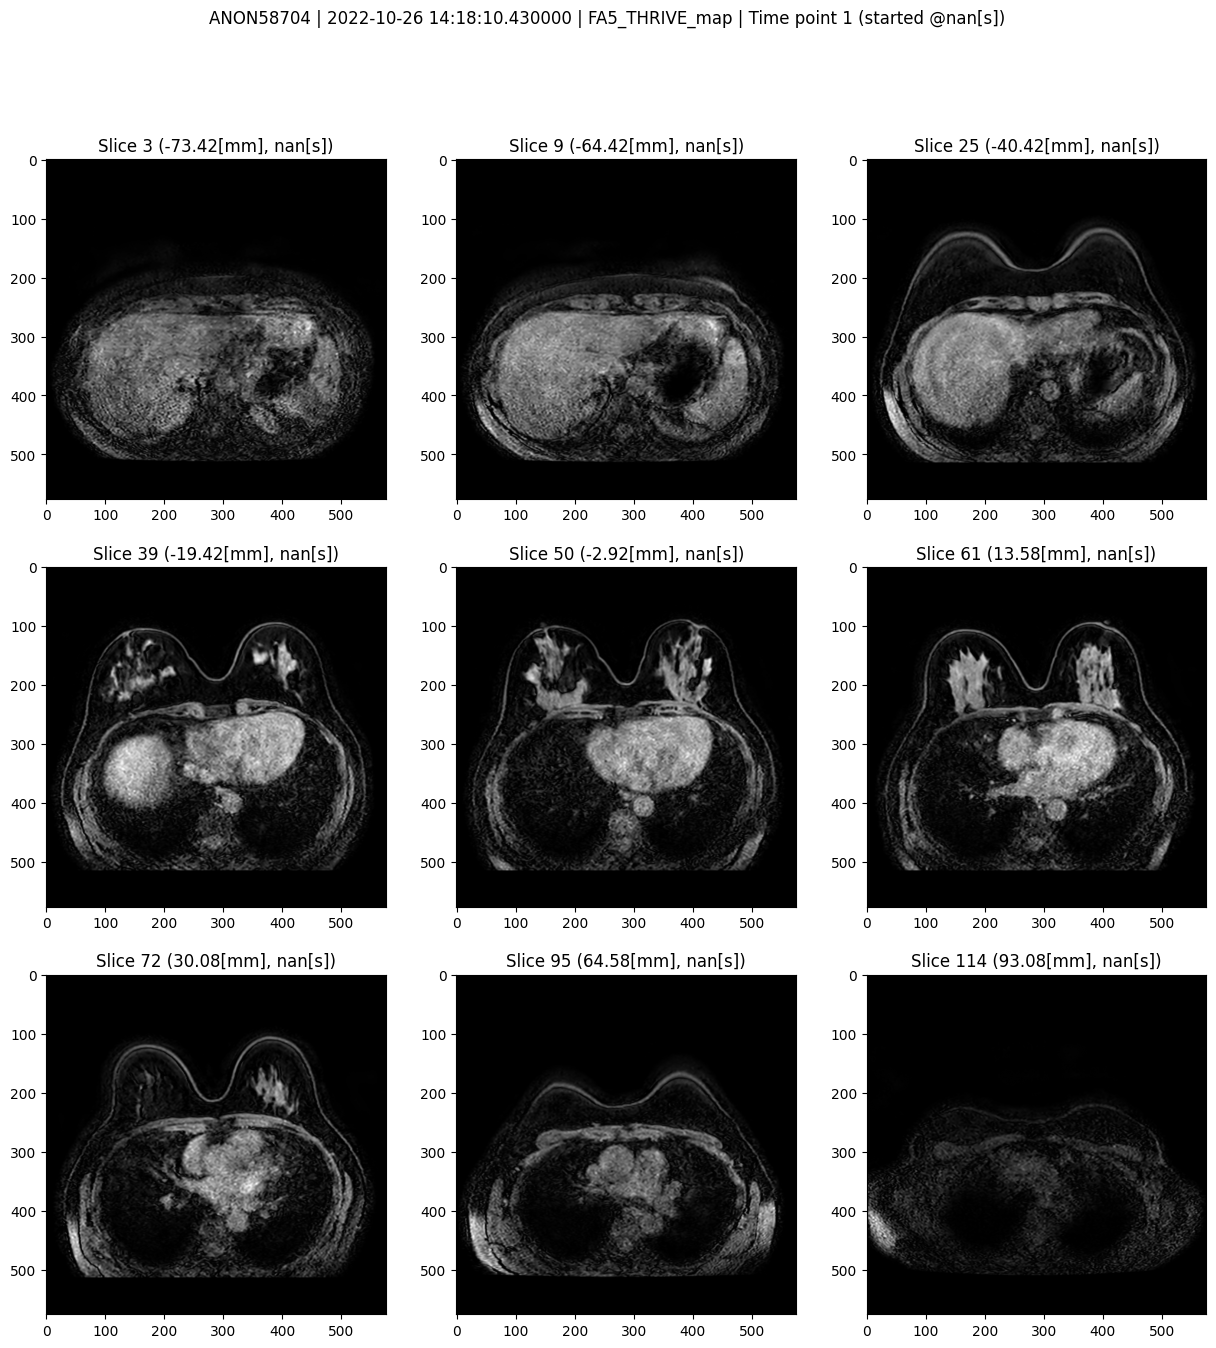

In [13]:
# This section is to plot several slices on a fixed time point (picked randomly). 
fig, ax = plt.subplots(nrows=nrows, ncols=ncols, figsize=(figHeight*ncols, figWidth*nrows))
axr = ax.ravel()

time_point_index = rng.choice(nt, 1, replace=False)[0]
# To fix the time to the start, use this:
# time_point_index = 0

time_position = time_point_index + 1

time_axis_secs = time_matrix[:, time_point_index]
slice_locations_mm = slice_position_matrix[:, time_point_index]

# pick randomly nfigs slices in a fixed time point:
selected_slices_indices = rng.choice(ns, nfigs, replace=False)
# To select slices from a fixed position and step, use this:
# selected_slices_indices = np.linspace(0, ns, endpoint=False, num=nfigs, dtype=int)

selected_slices_indices.sort()

fig.suptitle(f"{patient_to_load} | {scanDetails['scanDateTime']} | {scanDetails['sequenceName']} | Time point {time_position} (started @{time_axis_secs[0]:.2f}[s])")
for idx_fig in range(nfigs):
    # slice_position = slice_locations[selected_slices_indices[idx_fig]]
    slice_loc = selected_slices_indices[idx_fig]
    slice_position = slice_locations_mm[slice_loc, ]
    time_sec = time_axis_secs[slice_loc]

    axr[idx_fig].imshow(image4D[:,:,slice_loc, time_point_index], cmap='gray')
    axr[idx_fig].set_title(f"Slice {slice_loc} ({slice_position:.2f}[mm], {1*time_sec:.2f}[s])")
    

In [14]:
# This section is to plot same slice over time (relevant for dynamic series)
if nt > 1:

    fig, ax = plt.subplots(nrows=nrows, ncols=ncols, figsize=(figHeight*ncols, figWidth*nrows))
    axr = ax.ravel()

    # Pick up randomly a slice to plot
    slice_location_index = rng.choice(ns, 1, replace=False)[0]
    # To fix the slice, use this:
    # slice_location_index = 0
    slice_locations_mm = slice_position_matrix[slice_location_index, :]
    
    # Get the time points corresponding to the slice selected
    time_axis_secs = time_matrix[slice_location_index, :]

    fig.suptitle(f"{patient_to_load} | {scanDetails['scanDateTime']} | {scanDetails['sequenceName']} | Slice {slice_location_index} ({slice_locations_mm[0]:.2f}[mm])")
    for idx_fig in range(np.min([nfigs, nt])):
        slice_position = slice_locations_mm[idx_fig]
        time_sec = time_axis_secs[idx_fig]

        axr[idx_fig].imshow(image4D[:,:,slice_location_index, idx_fig], cmap='gray')
        axr[idx_fig].set_title(f"Slice acquisition time: {1*time_sec:.2f}[s]")
else:
    print(f"[INFO]: Sequence {scanDetails['sequenceName']} is not a dynamic series")


[INFO]: Sequence FA5_THRIVE_map is not a dynamic series


# Effect of the re-scaling DICOM attributes

In [15]:
# Selection of Dataset:
patientIdx = '001'
patient_to_load = patient_dictionary[patientIdx]
sequence_to_load = 'FA5' # 'FA5', 'FA15', 'Dyn', '4D'

# With Rescaling (default)
image_with_rescale_visit1, _, _, scanDetails_wrescale_v1 = get_image_dataset(df_metadata, patient_to_load, visit_to_load=1, sequenceNamePattern=sequence_to_load)
image_with_rescale_visit2, _, _, scanDetails_wrescale_v2 = get_image_dataset(df_metadata, patient_to_load, visit_to_load=2, sequenceNamePattern=sequence_to_load)
[w, h, ns, nt] = image_with_rescale_visit1.shape

# With no rescaling:
image_without_rescale_visit1, _, _, scanDetails_worescale_v1 = get_image_dataset(df_metadata, patient_to_load, visit_to_load=1, sequenceNamePattern=sequence_to_load, use_philips_rescale=False)
image_without_rescale_visit2, _, _, scanDetails_worescale_v2 = get_image_dataset(df_metadata, patient_to_load, visit_to_load=2, sequenceNamePattern=sequence_to_load, use_philips_rescale=False)

# Get some basic stats and calculations:
image_diff_visits_wrescale = np.abs(image_with_rescale_visit1 - image_with_rescale_visit2)
image_diff_visits_worescale = np.abs(image_without_rescale_visit1 - image_without_rescale_visit2)

[min_wrescale_v1, max_wrescale_v1] = [image_with_rescale_visit1.min(), image_with_rescale_visit1.max()]
[min_worescale_v1, max_worescale_v1] = [image_without_rescale_visit1.min(), image_without_rescale_visit1.max()]
[min_wrescale_v2, max_wrescale_v2] = [image_with_rescale_visit2.min(), image_with_rescale_visit2.max()]
[min_worescale_v2, max_worescale_v2] = [image_without_rescale_visit2.min(), image_without_rescale_visit2.max()]

[min_diff_wrescale, max_diff_wrescale] = [image_diff_visits_wrescale.min(), image_diff_visits_wrescale.max()]
[min_diff_worescale, max_diff_worescale] = [image_diff_visits_worescale.min(), image_diff_visits_worescale.max()]

print(f'Min/Max ABS Difference WITH RESCALE: [{min_diff_wrescale}, {max_diff_wrescale}]')
print(f'Min/Max ABS Difference WITHOUT RESCALE: [{min_diff_worescale}, {max_diff_worescale}]')


Selected Patient ANON58704, visit 1, Sequence FA5_THRIVE_map (from 26/10/2022 @14:18:10)
Dataset ANON58704-20221026-FA5_THRIVE_map contains 120 slices and 1 temporal positions of size 576x576 (WxH)
Image resolution is 0.619x0.619x3.00 [mm/pixel] (WxHxZ)
Selected Patient ANON58704, visit 2, Sequence FA5_THRIVE_map (from 15/12/2022 @10:52:17)
Dataset ANON58704-20221215-FA5_THRIVE_map contains 120 slices and 1 temporal positions of size 576x576 (WxH)
Image resolution is 0.619x0.619x3.00 [mm/pixel] (WxHxZ)
Selected Patient ANON58704, visit 1, Sequence FA5_THRIVE_map (from 26/10/2022 @14:18:10)
Dataset ANON58704-20221026-FA5_THRIVE_map contains 120 slices and 1 temporal positions of size 576x576 (WxH)
Image resolution is 0.619x0.619x3.00 [mm/pixel] (WxHxZ)
Selected Patient ANON58704, visit 2, Sequence FA5_THRIVE_map (from 15/12/2022 @10:52:17)
Dataset ANON58704-20221215-FA5_THRIVE_map contains 120 slices and 1 temporal positions of size 576x576 (WxH)
Image resolution is 0.619x0.619x3.00 [mm

Text(0.5, 1.0, 'Histogram Image WITHOUT Rescaling')

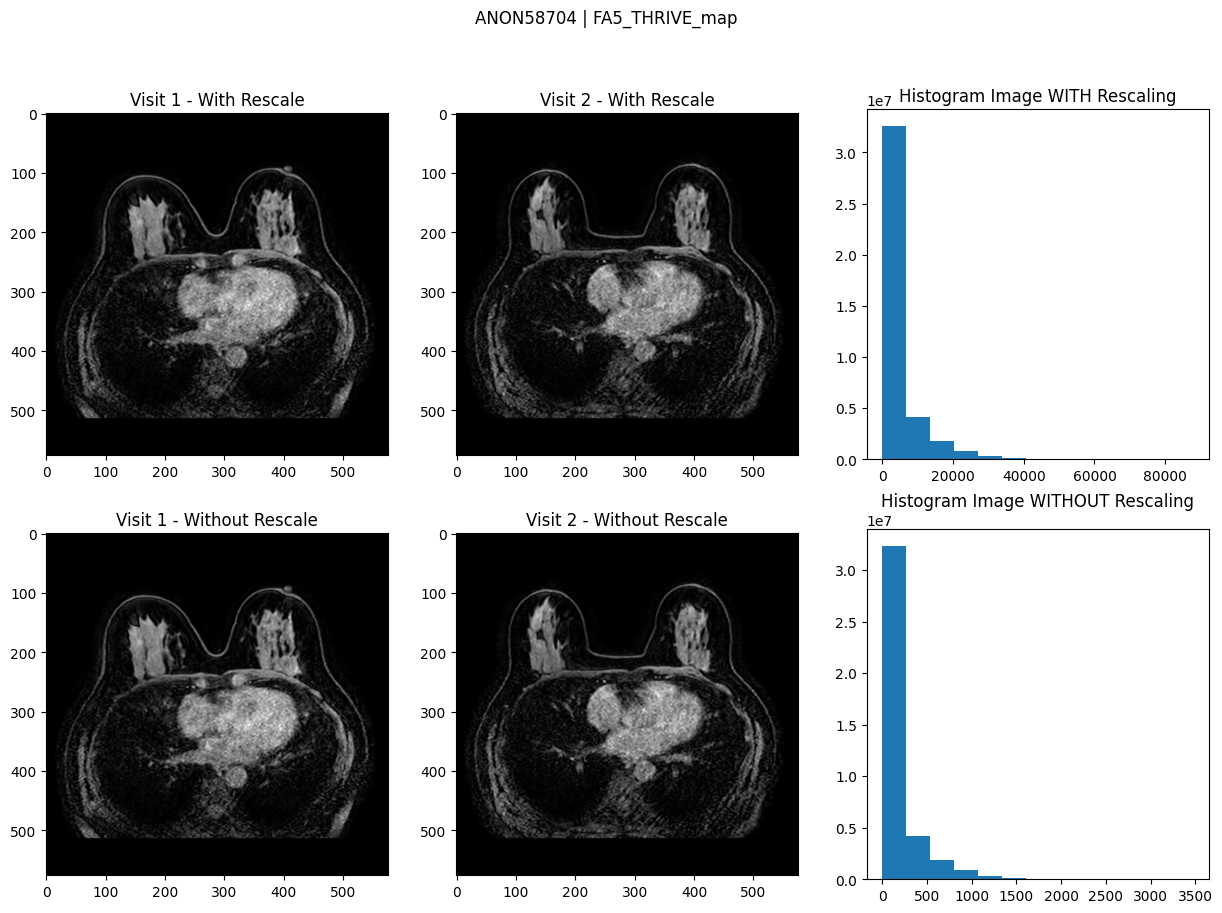

In [16]:
# Compare two slices of the same acquisition, with and without re-scaling
slice_to_compare = ns // 2 # central slice
[figWidth, figHeight] = [5.0, 5.0]
nfigs = 6
ncols = int(np.ceil(np.sqrt(nfigs)))
nrows = int(np.ceil(nfigs/ncols))

fig, ax = plt.subplots(nrows=nrows, ncols=ncols, figsize=(figHeight*ncols, figWidth*nrows))
fig.suptitle(f"{patient_to_load} | {scanDetails_wrescale_v1['sequenceName']} ")

axr = ax.ravel()

axr[0].imshow(image_with_rescale_visit1[:, :, slice_to_compare, :], cmap='gray')
axr[0].set_title('Visit 1 - With Rescale')

axr[1].imshow(image_with_rescale_visit2[:, :, slice_to_compare, :], cmap='gray')
axr[1].set_title('Visit 2 - With Rescale')

axr[2].hist(image_diff_visits_wrescale.ravel(), 2^(int(np.log2(max_diff_wrescale))) - 1)
axr[2].set_title('Histogram Image WITH Rescaling')
# axr[2].imshow(image_diff_visits_wrescale[:, :, slice_to_compare, :], cmap='gray')
# axr[2].set_title('Difference (magnitude)')


axr[3].imshow(image_without_rescale_visit1[:, :, slice_to_compare, :], cmap='gray')
axr[3].set_title('Visit 1 - Without Rescale')

axr[4].imshow(image_without_rescale_visit2[:, :, slice_to_compare, :], cmap='gray')
axr[4].set_title('Visit 2 - Without Rescale')

axr[5].hist(image_diff_visits_worescale.ravel(), 2^(int(np.log2(max_diff_wrescale))) - 1)
axr[5].set_title('Histogram Image WITHOUT Rescaling')
# axr[5].imshow(image_diff_visits_worescale[:, :, slice_to_compare, :], cmap='gray')
# axr[5].set_title('Difference (magnitude)')



In [17]:
# Signal Intensity with/out rescaling dynamic series (ultrafast)
# Selection of Dataset:
patientIdx = '004'
patient_to_load = patient_dictionary[patientIdx]
sequence_to_load = '4D' # 'FA5', 'FA15', 'Dyn', '4D'
tumour_slice_position_v1 = [102, 209, 76]
tumour_slice_position_v2 = [130, 176, 74]


# With Rescaling (default)
dyn_image_wrescaling_v1, _, time_axes_wrescale_v1, dyn_scanDetails_wrescaling_v1 = get_image_dataset(df_metadata, patient_to_load, visit_to_load=1, sequenceNamePattern=sequence_to_load)
[w, h, ns, nt] = dyn_image_wrescaling_v1.shape
dyn_image_wrescaling_v2, _, time_axes_wrescale_v2, dyn_scanDetails_wrescaling_v2 = get_image_dataset(df_metadata, patient_to_load, visit_to_load=2, sequenceNamePattern=sequence_to_load)
# With no rescaling:
dyn_image_worescaling_v1, _, time_axes_worescale_v1, dyn_scanDetails_worescaling_v1 = get_image_dataset(df_metadata, patient_to_load, visit_to_load=1, sequenceNamePattern=sequence_to_load, use_philips_rescale=False)
dyn_image_worescaling_v2, _, time_axes_worescale_v2, dyn_scanDetails_worescaling_v2 = get_image_dataset(df_metadata, patient_to_load, visit_to_load=2, sequenceNamePattern=sequence_to_load, use_philips_rescale=False)


Selected Patient ANON44148, visit 1, Sequence 4D_THRIVE_Ultrafast (from 05/04/2023 @14:00:35)
Dataset ANON44148-20230405-4D_THRIVE_Ultrafast contains 120 slices and 28 temporal positions of size 528x528 (WxH)
Image resolution is 0.680x0.680x3.00 [mm/pixel] (WxHxZ)
Selected Patient ANON44148, visit 2, Sequence 4D_THRIVE_Ultrafast (from 11/05/2023 @10:16:20)
Dataset ANON44148-20230511-4D_THRIVE_Ultrafast contains 120 slices and 28 temporal positions of size 528x528 (WxH)
Image resolution is 0.680x0.680x3.00 [mm/pixel] (WxHxZ)
Selected Patient ANON44148, visit 1, Sequence 4D_THRIVE_Ultrafast (from 05/04/2023 @14:00:35)
Dataset ANON44148-20230405-4D_THRIVE_Ultrafast contains 120 slices and 28 temporal positions of size 528x528 (WxH)
Image resolution is 0.680x0.680x3.00 [mm/pixel] (WxHxZ)
Selected Patient ANON44148, visit 2, Sequence 4D_THRIVE_Ultrafast (from 11/05/2023 @10:16:20)
Dataset ANON44148-20230511-4D_THRIVE_Ultrafast contains 120 slices and 28 temporal positions of size 528x528 (W

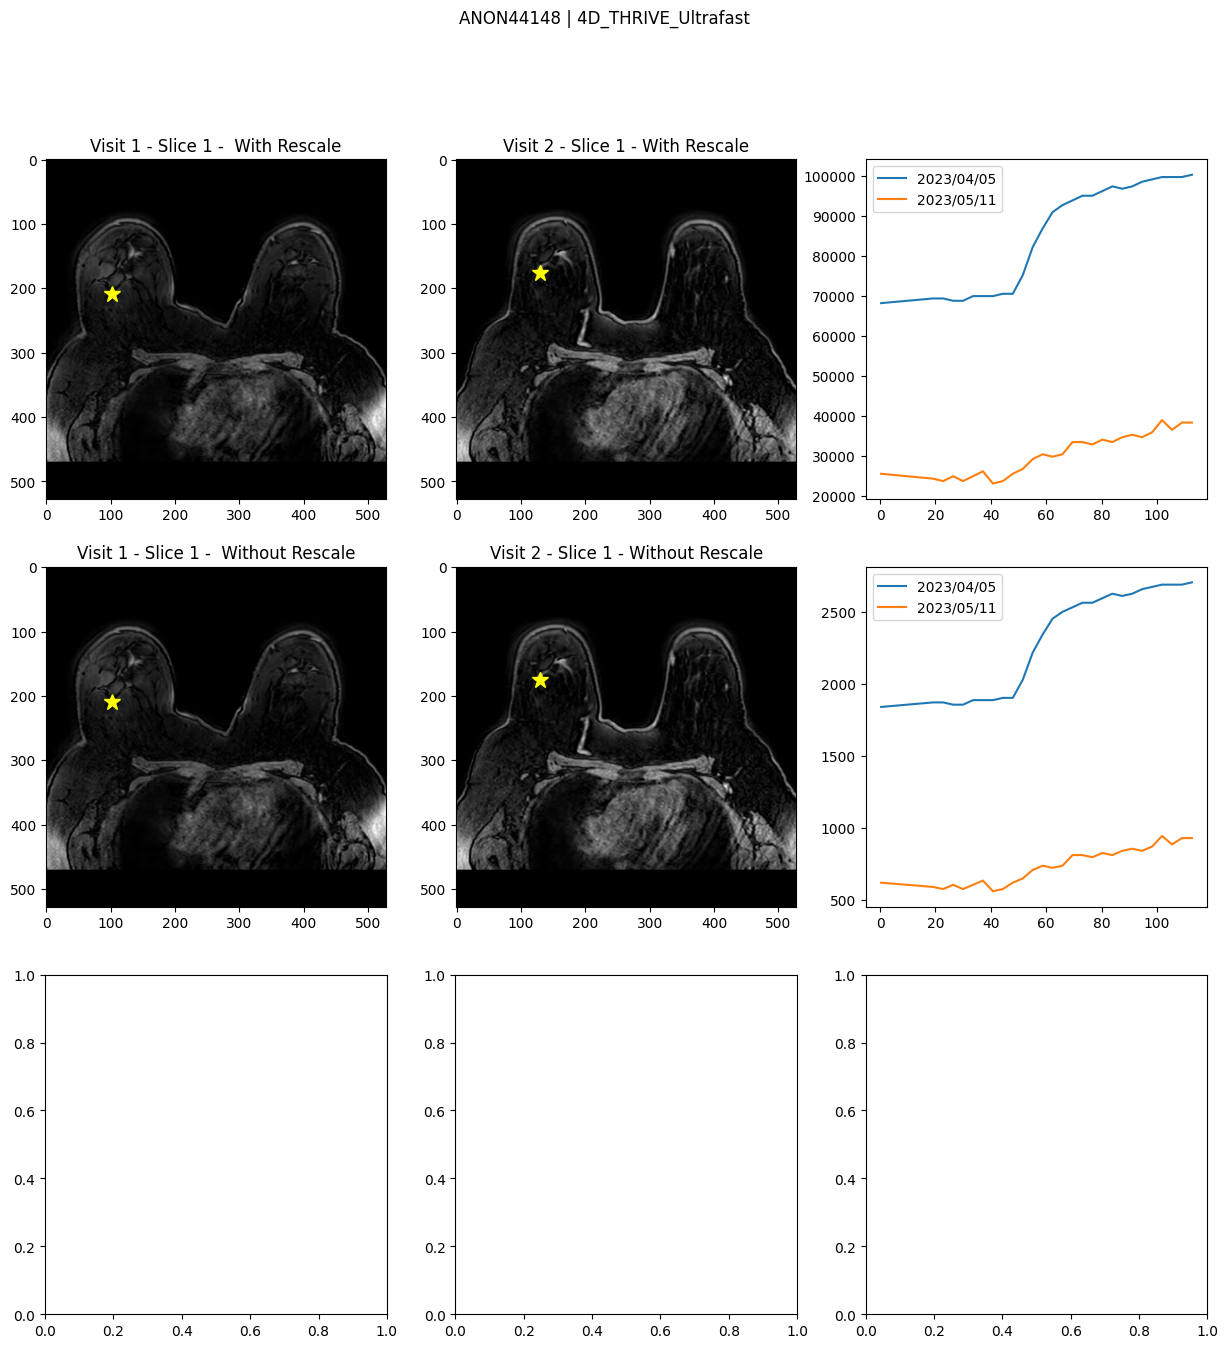

In [18]:
dynamic_line_wrescale_v1 = dyn_image_wrescaling_v1[tumour_slice_position_v1[1], 
                                                   tumour_slice_position_v1[0], 
                                                   tumour_slice_position_v1[-1], 
                                                   :].copy()
# dynamic_line_wrescale_v1 -= dynamic_line_wrescale_v1[0]
# dynamic_line_wrescale_v1 /= max(dynamic_line_wrescale_v1)

dynamic_line_worescale_v1 = dyn_image_worescaling_v1[tumour_slice_position_v1[1], 
                                                   tumour_slice_position_v1[0], 
                                                   tumour_slice_position_v1[-1], 
                                                   :].copy()
# dynamic_line_worescale_v1 -= dynamic_line_worescale_v1[0]
# dynamic_line_worescale_v1 /= max(dynamic_line_worescale_v1)

dynamic_line_wrescale_v2 = dyn_image_wrescaling_v2[tumour_slice_position_v2[1], 
                                                   tumour_slice_position_v2[0], 
                                                   tumour_slice_position_v2[-1], 
                                                   :].copy()
# dynamic_line_wrescale_v2 -= dynamic_line_wrescale_v2[0]
# dynamic_line_wrescale_v2 /= max(dynamic_line_wrescale_v2)

dynamic_line_worescale_v2 = dyn_image_worescaling_v2[tumour_slice_position_v2[1], 
                                                   tumour_slice_position_v2[0], 
                                                   tumour_slice_position_v2[-1], 
                                                   :].copy()
# dynamic_line_worescale_v2 -= dynamic_line_worescale_v2[0]
# dynamic_line_worescale_v2 /= max(dynamic_line_worescale_v2)

[figWidth, figHeight] = [5.0, 5.0]
nfigs = 9
ncols = int(np.ceil(np.sqrt(nfigs)))
nrows = int(np.ceil(nfigs/ncols))

fig, ax = plt.subplots(nrows=nrows, ncols=ncols, figsize=(figHeight*ncols, figWidth*nrows))
fig.suptitle(f"{patient_to_load} | {dyn_scanDetails_worescaling_v1['sequenceName']} ")

axr = ax.ravel()

axr[0].imshow(dyn_image_wrescaling_v1[:, :, tumour_slice_position_v1[-1], 0], cmap='gray')
axr[0].plot(tumour_slice_position_v1[0], tumour_slice_position_v1[1], '*', markersize=12, color='yellow')
axr[0].set_title('Visit 1 - Slice 1 -  With Rescale')

axr[1].imshow(dyn_image_wrescaling_v2[:, :, tumour_slice_position_v2[-1], 0], cmap='gray')
axr[1].plot(tumour_slice_position_v2[0], tumour_slice_position_v2[1], '*', markersize=12, color='yellow')
axr[1].set_title('Visit 2 - Slice 1 - With Rescale')

axr[2].plot(time_axes_wrescale_v1[tumour_slice_position_v1[-1],:]-time_axes_wrescale_v1[0,0], 
            dynamic_line_wrescale_v1,
            label=dtime.strftime(dyn_scanDetails_wrescaling_v1['scanDateTime'], '%Y/%m/%d'))
axr[2].plot(time_axes_wrescale_v2[tumour_slice_position_v2[-1],:]-time_axes_wrescale_v2[0,0], 
            dynamic_line_wrescale_v2, 
            label=dtime.strftime(dyn_scanDetails_wrescaling_v2['scanDateTime'], '%Y/%m/%d'))
axr[2].legend(loc='best')


axr[3].imshow(dyn_image_worescaling_v1[:, :, tumour_slice_position_v1[-1], 0], cmap='gray')
axr[3].plot(tumour_slice_position_v1[0], tumour_slice_position_v1[1], '*', markersize=12, color='yellow')
axr[3].set_title('Visit 1 - Slice 1 -  Without Rescale')

axr[4].imshow(dyn_image_worescaling_v2[:, :, tumour_slice_position_v2[-1], 0], cmap='gray')
axr[4].plot(tumour_slice_position_v2[0], tumour_slice_position_v2[1], '*', markersize=12, color='yellow')
axr[4].set_title('Visit 2 - Slice 1 - Without Rescale')

axr[5].plot(time_axes_worescale_v1[tumour_slice_position_v1[-1],:]-time_axes_worescale_v1[0,0], 
            dynamic_line_worescale_v1, 
            label=dtime.strftime(dyn_scanDetails_worescaling_v1['scanDateTime'], '%Y/%m/%d'))
axr[5].plot(time_axes_worescale_v2[tumour_slice_position_v2[-1],:]-time_axes_worescale_v2[0,0], 
            dynamic_line_worescale_v2, 
            label=dtime.strftime(dyn_scanDetails_worescaling_v2['scanDateTime'], '%Y/%m/%d'))
axr[5].legend(loc='best')


In conclusion, Philips Rescale attribute (0x2005,0x100E) doesn't make a difference in the relative difference between slices and series. However, to be on the safe side, **I'll use it by default in any subsequent analysis**.

Slicer3D doesn't use it when reconstructing the data. Therefore, I presume the PK modelling extension doesn't use it either.

# T1 estimation with the VFA method(s)
Although there are only two flip angles, I'm going to evaluate which method provides better results (based on the expected theoretical values).

From the notebook **TheoryOfVFA.ipynb** in the [DCE-DRO-PYTHON repository](https://github.com/iSANDEx/dce-dro-python):

SPGR signal equation: 
$$ S(T_1, T_R, \alpha, M_0) = M_0\sin(\alpha)\frac{1 - E_1(T_1,T_R)}{1 - E_1(T_1,T_R)\cos(\alpha)} $$
$$ E_1(T_1, T_R) = \exp(-T_R/T_1) $$

If we acquire multiple flip angles, keeping everything else constant, the equation \ref{spgr} can be linearised and T1 derived from the slope of such line:

$$ \frac{S_i}{\sin(\alpha_i)} = E_1\frac{S_i}{\tan(\alpha_i)} + M_0(1-E_1) $$
$$ \hat{Y}[i] = m\hat{X}[i] + n $$

with:
$$ \hat{Y}[i] = \frac{S_i}{\sin(\alpha_i)} $$
$$ \hat{X}[i] = \frac{S_i}{\tan(\alpha_i)} $$
$$ m = E_1 $$
$$ n = M_0(1-E1) $$

from which we can derived $T_1$ from the slope $m$:
$$ E_1 = m $$
$$ E_1 = \exp(-T_R/T_1) $$
$$ -\frac{T_R}{T_1} = \ln(E_1) $$
$$ T_1 = -\frac{T_R}{\ln(m)} $$

However, to improve stability, it is better to develop more the equations, as shown by [Helms et al., 2008](https://onlinelibrary.wiley.com/doi/full/10.1002/mrm.21542):
$$
\hat{T_1} = 2T_R \frac{\frac{S_1}{\alpha_1} - \frac{S_2}{\alpha_2}}{S_2\alpha_2 - S_1\alpha_1}
$$

In the simplest form, by knowing the $T_R$ and acquisition Flip Angles, we can determine the $T_1$ on a pixel-by-pixel basis

In [19]:
# Let's run an example
patientIdx = '004'
patient_to_load = patient_dictionary[patientIdx]
tumour_slice_position = [103, 212, 76]

fa5deg, _, _, fa5deg_details = get_image_dataset(df_metadata, patient_to_load, visit_to_load=1, sequenceNamePattern='FA5', use_philips_rescale=False)

fa15deg, _, _, fa15deg_details = get_image_dataset(df_metadata, patient_to_load, visit_to_load=1, sequenceNamePattern='FA15', use_philips_rescale=False)

[w, h, ns, nt] = fa5deg.shape


Selected Patient ANON44148, visit 1, Sequence FA5_THRIVE_map (from 05/04/2023 @13:59:26)
Dataset ANON44148-20230405-FA5_THRIVE_map contains 120 slices and 1 temporal positions of size 528x528 (WxH)
Image resolution is 0.680x0.680x3.00 [mm/pixel] (WxHxZ)
Selected Patient ANON44148, visit 1, Sequence FA15_THRIVE_map (from 05/04/2023 @14:00:00)
Dataset ANON44148-20230405-FA15_THRIVE_map contains 120 slices and 1 temporal positions of size 528x528 (WxH)
Image resolution is 0.680x0.680x3.00 [mm/pixel] (WxHxZ)


In [20]:
# attempt registering the T1W images: FA15 -> FA5



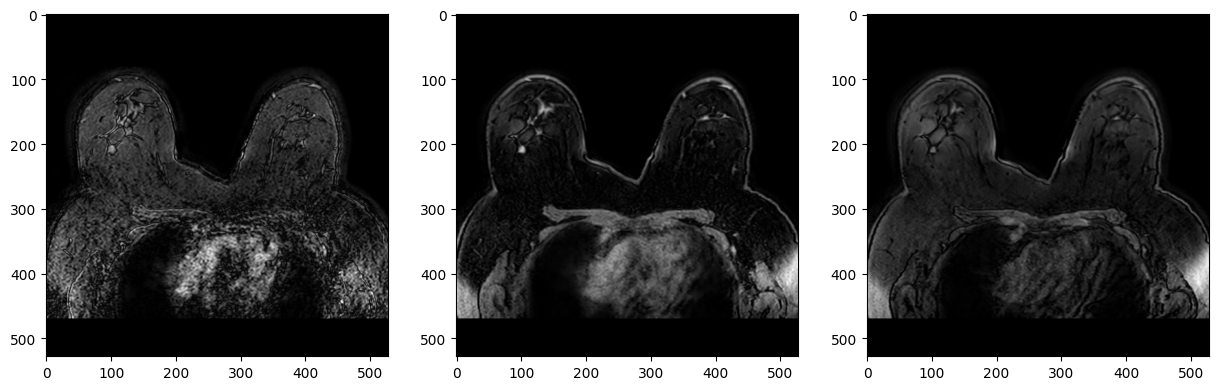

In [21]:
# Check level of motion between both FA
fig, ax = plt.subplots(1,3,figsize=(3*5.0, 5.0))
ax[0].imshow(np.abs(fa5deg/fa5deg.max() - fa15deg/fa15deg.max())[:,:,tumour_slice_position[-1]], cmap='gray')
ax[1].imshow(fa5deg[:,:,tumour_slice_position[-1]], cmap='gray')
ax[2].imshow(fa15deg[:,:,tumour_slice_position[-1]], cmap='gray')


In [22]:
# sinAlfai = np.sin(np.deg2rad([fa5deg_details['FA'][0], 
#                               fa15deg_details['FA'][0]]))
# tanAlfai = np.tan(np.deg2rad([fa5deg_details['FA'][0], 
#                               fa15deg_details['FA'][0]]))

alfa_i = np.deg2rad([fa5deg_details['FA'][0], 
                    fa15deg_details['FA'][0]])

TR_fa5deg = fa5deg_details['TR'][0]
TR_fa15deg = fa15deg_details['TR'][0]
TR = np.mean([TR_fa5deg, TR_fa15deg]) # * np.mean([fa5deg_details['ETL'][0], fa15deg_details['ETL'][0]])

if TR_fa15deg != TR_fa15deg: 
    print('WARNING: TR are not the same for the 5 and 15 degree acquisitions')
    print(f'TR (FA=5deg): {TR_fa5deg:.3f}ms')
    print(f'TR (FA=15deg): {TR_fa15deg:.3f}ms')
else:
    print(f'TR = {TR:.2f}ms')

# yhat = np.vstack( (fa5deg.flatten() / sinAlfai[0], 
#                    fa15deg.flatten() / sinAlfai[1] ) )
# xhat = np.vstack( (fa5deg.flatten() / tanAlfai[0], 
#                    fa15deg.flatten() / tanAlfai[1] ) )

# mhat = np.diff(yhat, axis=0) / (np.diff(xhat, axis=0) + 1e-3)
# mhat[mhat < 0] = 0
# T1hat = - TR / np.log(mhat + 1e-3)
# T1hat[np.abs(T1hat) > 5e3] = 0
# T1hat[T1hat<0] = 0
# T1map = np.reshape(T1hat, (w, h, ns))

T1num = (fa5deg / alfa_i[0]) - (fa15deg / alfa_i[1])
T1den = (fa15deg * alfa_i[1]) - (fa5deg * alfa_i[0])

T1map = np.squeeze(2 * TR * T1num / T1den )
T1map[np.isnan(T1map)] = 0
T1map[T1map > 5e3] = 0
T1map[T1map < 0] = 0
# export T1map:
img = nib.Nifti1Image(T1map, np.eye(4))  # Save axis for data (just identity)
img.header.get_xyzt_units()
img.to_filename(os.path.join(OUTPATH, f"t1map_{patient_to_load} - {dtime.strftime(fa15deg_details['scanDateTime'], '%Y%m%d')}.nii.gz"))


print(f'Estimated T1 value within the tumour: {T1map[tumour_slice_position[1], tumour_slice_position[0], tumour_slice_position[-1]]:.2f}[ms]')


TR = 5.18ms


/var/folders/0v/y90qwty54psg4dqwj7dg8sl40000gn/T/ipykernel_34327/1321599802.py:35: RuntimeWarning: invalid value encountered in divide
  T1map = np.squeeze(2 * TR * T1num / T1den )


Estimated T1 value within the tumour: 605.08[ms]


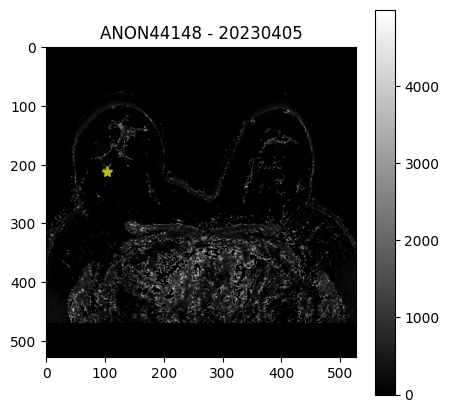

In [23]:
fig, ax = plt.subplots(1, 1, figsize=(5.0, 5.0))
pos = ax.imshow(T1map[:, :, tumour_slice_position[-1]], cmap='gray')
ax.set_title(f"{patient_to_load} - {dtime.strftime(fa5deg_details['scanDateTime'], '%Y%m%d')}")
ax.plot(tumour_slice_position[0], tumour_slice_position[1], 'y*', markersize=8)
fig.colorbar(pos, ax=ax)


In [24]:
fa5degITK, _, _, _ = get_image_dataset(df_metadata, patient_to_load, visit_to_load=1, sequenceNamePattern='FA5', use_philips_rescale=False)
fa5degITK[212, 103, 76]


Selected Patient ANON44148, visit 1, Sequence FA5_THRIVE_map (from 05/04/2023 @13:59:26)
Dataset ANON44148-20230405-FA5_THRIVE_map contains 120 slices and 1 temporal positions of size 528x528 (WxH)
Image resolution is 0.680x0.680x3.00 [mm/pixel] (WxHxZ)


array([1786.63134766])

In [25]:
fa5deg[212, 103, 76]


array([1786.63134766])

In [26]:
T1map[212, 103, 76]


np.float64(605.0774564184977)